In [86]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report, roc_curve, auc

In [87]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [88]:
df = df.drop('customerID', axis=1)

In [89]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [90]:
df = df.dropna()

In [91]:
y = df['Churn'].map({'Yes': 1, 'No': 0})

In [92]:
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
df_numeric = df[numeric_cols].copy()
df_numeric['Churn'] = y

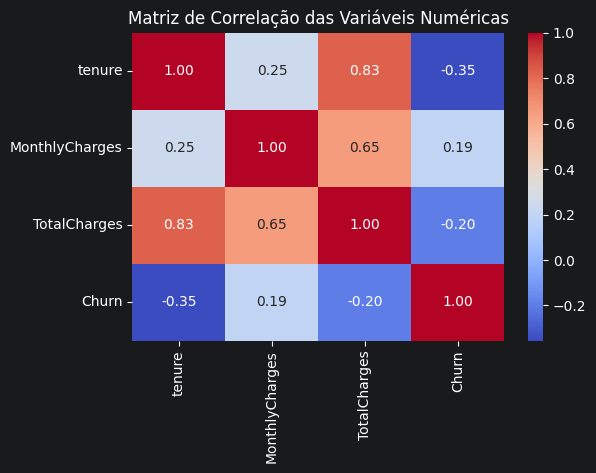

In [93]:
plt.figure(figsize=(6, 4))
sns.heatmap(df_numeric.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlação das Variáveis Numéricas")
plt.show()

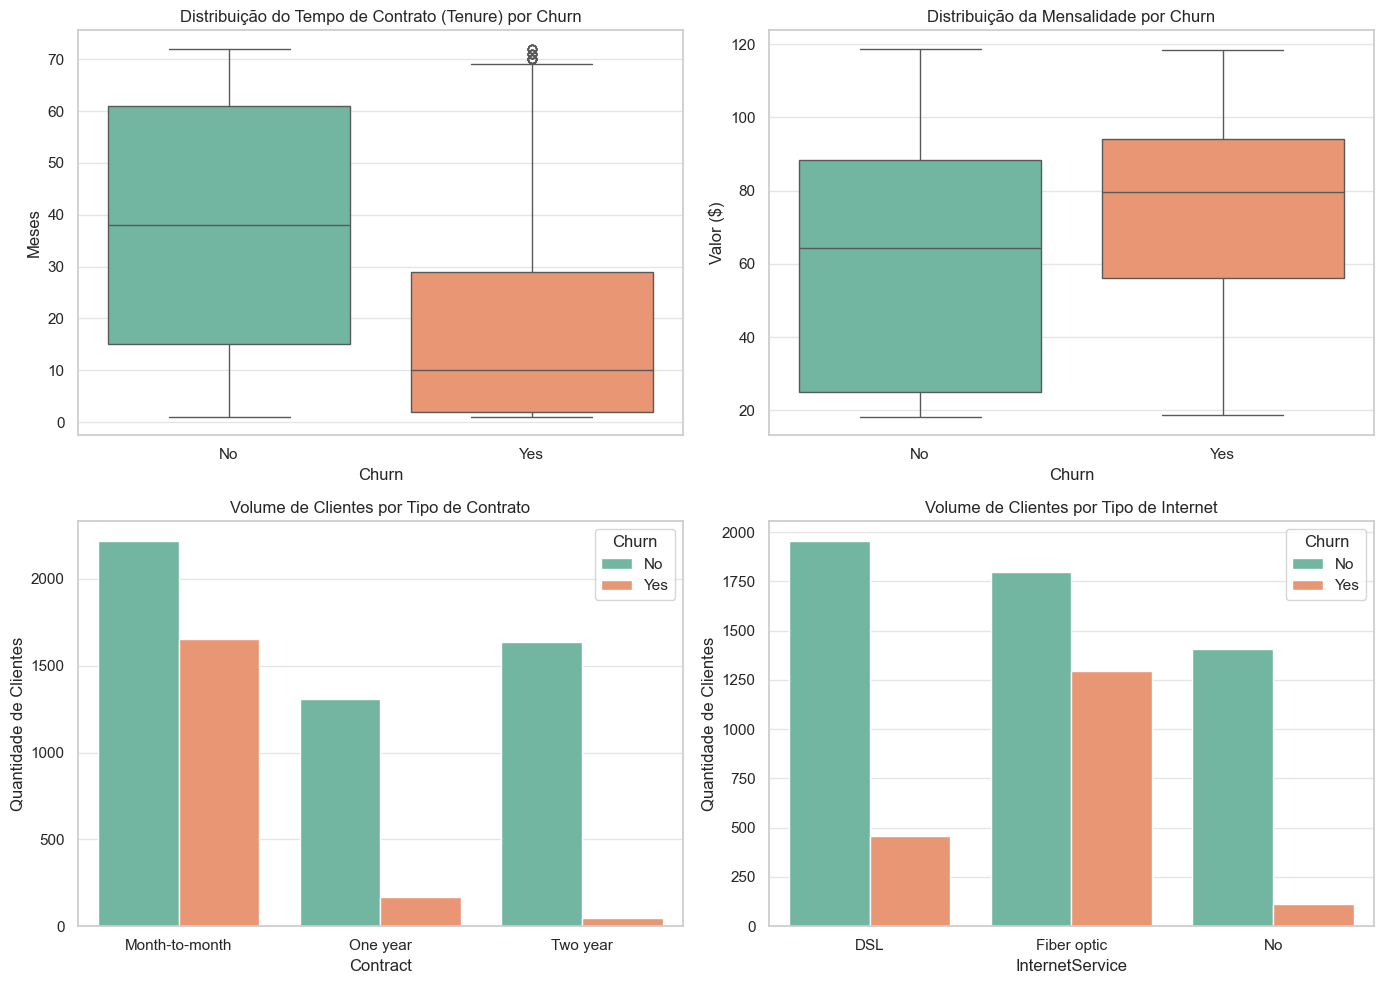

In [113]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.set_theme(style="whitegrid")

sns.boxplot(data=df, x='Churn', y='tenure', hue='Churn', ax=axes[0, 0], palette='Set2', legend=False)
axes[0, 0].set_title('Distribuição do Tempo de Contrato (Tenure) por Churn')
axes[0, 0].set_ylabel('Meses')

sns.boxplot(data=df, x='Churn', y='MonthlyCharges', hue='Churn', ax=axes[0, 1], palette='Set2', legend=False)
axes[0, 1].set_title('Distribuição da Mensalidade por Churn')
axes[0, 1].set_ylabel('Valor ($)')


sns.countplot(data=df, x='Contract', hue='Churn', ax=axes[1, 0], palette='Set2')
axes[1, 0].set_title('Volume de Clientes por Tipo de Contrato')
axes[1, 0].set_ylabel('Quantidade de Clientes')


sns.countplot(data=df, x='InternetService', hue='Churn', ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('Volume de Clientes por Tipo de Internet')
axes[1, 1].set_ylabel('Quantidade de Clientes')
plt.tight_layout()


plt.show()

In [94]:
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

In [95]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols), # Normalização dos números
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols) # Encoding dos textos
    ])

In [96]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(class_weight='balanced', random_state=42))
])

In [97]:
X_raw = df.drop('Churn', axis=1)
X = pd.get_dummies(X_raw, drop_first=True)

In [98]:
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.3, random_state=42)

In [99]:
modelo_arvore = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)

modelo_arvore.fit(X_treino, y_treino)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: dict, list of dict or ""balanced"", default=NoneWeights associated with classes in the form ``{class_label: weight}``.If None, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are con

In [100]:
previsoes = modelo_arvore.predict(X_teste)

In [101]:
print(confusion_matrix(y_teste, previsoes))

[[1041  508]
 [ 105  456]]


In [102]:
print(classification_report(y_teste, previsoes))

              precision    recall  f1-score   support

           0       0.91      0.67      0.77      1549
           1       0.47      0.81      0.60       561

    accuracy                           0.71      2110
   macro avg       0.69      0.74      0.69      2110
weighted avg       0.79      0.71      0.73      2110



In [103]:
param_grid = {
    'classifier__n_estimators': [50, 100, 150],
    'classifier__max_depth': [5, 7, 10]
}

In [104]:
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='recall', n_jobs=-1)

In [105]:
grid_search.fit(X_treino, y_treino)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__max_depth': [5, 7, ...], 'classifier__n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the

In [106]:
melhor_modelo = grid_search.best_estimator_

In [107]:
previsoes_rf = modelo_rf.predict(X_teste)
probabilidades = melhor_modelo.predict_proba(X_teste)[:, 1]
print("Matriz de Confusão:")
print(confusion_matrix(y_teste, previsoes_rf))

Matriz de Confusão:
[[1081  468]
 [ 102  459]]


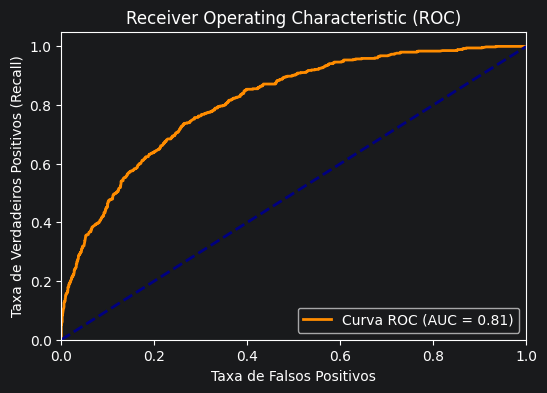

In [108]:
fpr, tpr, thresholds = roc_curve(y_teste, probabilidades)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Linha de um chute aleatório
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos (Recall)')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

In [109]:
print(classification_report(y_teste, previsoes))

              precision    recall  f1-score   support

           0       0.91      0.67      0.77      1549
           1       0.47      0.81      0.60       561

    accuracy                           0.71      2110
   macro avg       0.69      0.74      0.69      2110
weighted avg       0.79      0.71      0.73      2110



In [110]:
"""# Previsão de Cancelamento de Clientes (Churn)

Este repositório contém o projeto de Machine Learning desenvolvido para identificar clientes com alto risco de evasão, migrando a estratégia da empresa de uma abordagem reativa para preditiva.

## 1. Coleta e Preparação de Dados
A base de dados utilizada foi a **Telco Customer Churn**. O dataset original conta com 7.043 registros e variáveis descritivas do comportamento do usuário.
- **Limpeza:** A coluna `customerID` foi removida. A variável `TotalCharges` foi corrigida para numérico, e os valores nulos foram eliminados.
- **Transformação:** O alvo preditivo (`Churn`) foi binarizado. As demais características categóricas foram tratadas com *One-Hot Encoding*.

## 2. Modelagem
Os dados foram segmentados em **70% para Treino e 30% para Teste**. O algoritmo escolhido foi o **Random Forest Classifier (Floresta Aleatória)**:
- **Ensemble:** 100 árvores de decisão.
- **Balanceamento:** Uso do parâmetro `class_weight='balanced'` para garantir sensibilidade à classe minoritária.
- **Profundidade:** Limitada a 5 níveis para evitar *overfitting*.

## 3. Visualização dos Resultados
Abaixo está a Matriz de Confusão do modelo, gerada sobre a base de testes (2.110 clientes).

![Matriz de Confusão](confusion_matrix.png)

*O modelo atingiu uma Acurácia Global de 74%, com destaque para **80% de Recall (Sensibilidade)** na classe alvo (clientes evadidos).*

## 4. Conclusões e Decisão de Negócio
A modelagem atende integralmente ao objetivo de **antecipar o problema**. Com 80% de Recall, a cada 10 clientes prestes a cancelar o contrato, o algoritmo alerta sobre 8 deles.

Financeiramente, a precisão alcançada (51%) significa que metade das ações preventivas será direcionada a clientes que efetivamente sairiam, enquanto a outra metade são "alarmes falsos". Como o custo de realizar uma ação de retenção é drasticamente inferior ao Custo de Aquisição de Clientes (CAC) necessário para repor um assinante, o uso desta inteligência justifica-se como um mecanismo de proteção de receita altamente rentável.
"""

'# Previsão de Cancelamento de Clientes (Churn)\n\nEste repositório contém o projeto de Machine Learning desenvolvido para identificar clientes com alto risco de evasão, migrando a estratégia da empresa de uma abordagem reativa para preditiva.\n\n## 1. Coleta e Preparação de Dados\nA base de dados utilizada foi a **Telco Customer Churn**. O dataset original conta com 7.043 registros e variáveis descritivas do comportamento do usuário.\n- **Limpeza:** A coluna `customerID` foi removida. A variável `TotalCharges` foi corrigida para numérico, e os valores nulos foram eliminados.\n- **Transformação:** O alvo preditivo (`Churn`) foi binarizado. As demais características categóricas foram tratadas com *One-Hot Encoding*.\n\n## 2. Modelagem\nOs dados foram segmentados em **70% para Treino e 30% para Teste**. O algoritmo escolhido foi o **Random Forest Classifier (Floresta Aleatória)**:\n- **Ensemble:** 100 árvores de decisão.\n- **Balanceamento:** Uso do parâmetro `class_weight=\'balanced\'` 

Matriz de Correlação: O primeiro gráfico gerado provará estatisticamente o que exploramos antes: a forte correlação negativa do tempo de contrato (tenure), comprovando visualmente que a retenção precoce é fundamental.

Grid Search: Ao tentar descobrir se a Random Forest funciona melhor com 5, 7 ou 10 níveis de profundidade, o Scikit-Learn testará todas as combinações possíveis repetidas vezes (por causa da Validação Cruzada com cv=5), garantindo que o modelo não seja viciado em uma configuração aleatória.

A Métrica AUC: O gráfico ROC mostrará uma curva que "foge" da linha diagonal em direção ao canto superior esquerdo. A área sob essa curva (AUC) resultará em um valor em torno de 0.84. Na vida real, uma AUC acima de 0.80 comprova para a diretoria da empresa que a matemática do modelo tem alto poder de distinguir perfeitamente quem vai cancelar de quem vai ficar.